# Análisis de Microacciones Según Estado Emocional Previo

## Pregunta de Investigación

En este estudio me propongo responder a la siguiente pregunta: ¿Qué microacciones funcionan mejor según el estado emocional previo del usuario, más allá de la percepción consciente?

Para abordar esta cuestión, he desarrollado una metodología que combina normalización por usuario, segmentación por estado emocional y clustering para identificar patrones latentes en la efectividad de microacciones según el contexto emocional del usuario.

### Metodología

La metodología implementada consta de cinco fases principales: normalización por usuario mediante Z-score para eliminar sesgos personales en las calificaciones, segmentación interpretable para establecer reglas claras por estado emocional, análisis cruzado entre microacción y estado emocional para determinar efectividad, aplicación de clustering para identificar patrones emergentes, y validación sistémica para asegurar la coherencia de los resultados.

## Carga y Exploración de Datos

In [2]:
import pandas as pd
import numpy as np
from scipy.stats import zscore
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración para visualización
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Cargar datos (ajustando la ruta para usar el archivo real)
df = pd.read_csv("feedbacks_microacciones.csv")

# Mostrar información básica del dataset
print("INFORMACIÓN BÁSICA DEL DATASET")
print("="*50)
print(f"Forma del dataset: {df.shape}")
print(f"Columnas disponibles:\n{list(df.columns)}")
print(f"\nPrimeras 5 filas:")
df.head()

INFORMACIÓN BÁSICA DEL DATASET
Forma del dataset: (33, 11)
Columnas disponibles:
['usuario_id', 'nombre', 'timestamp', 'dia', 'microaccion', 'efectividad', 'comodidad', 'energia', 'felicidad_previa', 'estres_previo', 'motivacion_previa']

Primeras 5 filas:


,usuario_id,nombre,timestamp,dia,microaccion,efectividad,comodidad,energia,felicidad_previa,estres_previo,motivacion_previa
0,1,Ana,2026-02-04T11:44:00,1,estiramientos,4,5,1,0.64,0.54,0.23
1,1,Ana,2026-02-05T11:02:00,2,música relajante,4,4,3,0.62,0.46,0.44
2,1,Ana,2026-02-05T15:48:00,2,respiración profunda,5,3,4,0.33,0.41,0.55
3,1,Ana,2026-02-05T12:21:00,2,meditación,4,3,1,0.55,0.42,0.20
4,1,Ana,2026-02-07T16:12:00,4,caminata,5,3,3,0.31,0.72,0.32


In [3]:
# Definir columnas clave para el análisis
cols_estado = ["felicidad_previa", "estres_previo", "motivacion_previa"]
cols_feedback = ["efectividad", "comodidad", "energia"]

print("COLUMNAS CLAVE IDENTIFICADAS")
print("="*40)
print(f"Estados emocionales: {cols_estado}")
print(f"Métricas de feedback: {cols_feedback}")

# Exploración básica de usuarios y microacciones
print(f"\nUSUARIOS ÚNICOS: {df['usuario_id'].nunique()}")
print(f"USUARIOS: {df['nombre'].unique()}")

print(f"\nMICROACCIONES ÚNICAS: {df['microaccion'].nunique()}")
print(f"MICROACCIONES DISPONIBLES:")
for microaccion in df['microaccion'].unique():
    count = df['microaccion'].value_counts()[microaccion]
    print(f"   - {microaccion}: {count} registros")

COLUMNAS CLAVE IDENTIFICADAS
Estados emocionales: ['felicidad_previa', 'estres_previo', 'motivacion_previa']
Métricas de feedback: ['efectividad', 'comodidad', 'energia']

USUARIOS ÚNICOS: 3
USUARIOS: ['Ana' 'Carlos' 'Luna']

MICROACCIONES ÚNICAS: 12
MICROACCIONES DISPONIBLES:
   - estiramientos: 4 registros
   - música relajante: 3 registros
   - respiración profunda: 2 registros
   - meditación: 3 registros
   - caminata: 1 registros
   - té caliente: 4 registros
   - escribir gratitud: 3 registros
   - llamar amigo: 1 registros
   - arte/dibujo: 6 registros
   - baño relajante: 3 registros
   - lectura: 2 registros
   - ejercicio suave: 1 registros


## Verificación de Calidad de Datos

In [5]:
# Verificar valores faltantes
print("VERIFICACIÓN DE VALORES FALTANTES")
print("="*45)
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0] if missing_values.sum() > 0 else "No hay valores faltantes")

# Verificar tipos de datos
print(f"\nTIPOS DE DATOS")
print("="*20)
print(df.dtypes)

# Verificar rangos de valores para columnas emocionales y de feedback
print(f"\nRANGOS DE VALORES")
print("="*25)
columnas_numericas = cols_estado + cols_feedback
for col in columnas_numericas:
    print(f"{col}:")
    print(f"   Min: {df[col].min():.3f} | Max: {df[col].max():.3f} | Media: {df[col].mean():.3f}")
    print(f"   Rango válido: 0-1 para estados emocionales, 1-5 para feedback")
    
# Verificar si hay valores fuera de rango esperado
print(f"\nVERIFICACIÓN DE RANGOS")
print("="*30)
problemas = False

# Estados emocionales deben estar entre 0 y 1
for col in cols_estado:
    fuera_rango = df[(df[col] < 0) | (df[col] > 1)]
    if len(fuera_rango) > 0:
        print(f"PROBLEMA - {col}: {len(fuera_rango)} valores fuera del rango 0-1")
        problemas = True

# Feedback debe estar entre 1 y 5
for col in cols_feedback:
    fuera_rango = df[(df[col] < 1) | (df[col] > 5)]
    if len(fuera_rango) > 0:
        print(f"PROBLEMA - {col}: {len(fuera_rango)} valores fuera del rango 1-5")
        problemas = True

if not problemas:
    print("Todos los valores están en rangos válidos")

VERIFICACIÓN DE VALORES FALTANTES
No hay valores faltantes

TIPOS DE DATOS
usuario_id             int64
nombre                object
timestamp             object
dia                    int64
microaccion           object
efectividad            int64
comodidad              int64
energia                int64
felicidad_previa     float64
estres_previo        float64
motivacion_previa    float64
dtype: object

RANGOS DE VALORES
felicidad_previa:
   Min: 0.240 | Max: 0.800 | Media: 0.496
   Rango válido: 0-1 para estados emocionales, 1-5 para feedback
estres_previo:
   Min: 0.120 | Max: 0.830 | Media: 0.493
   Rango válido: 0-1 para estados emocionales, 1-5 para feedback
motivacion_previa:
   Min: 0.200 | Max: 0.860 | Media: 0.521
   Rango válido: 0-1 para estados emocionales, 1-5 para feedback
efectividad:
   Min: 2.000 | Max: 5.000 | Media: 3.333
   Rango válido: 0-1 para estados emocionales, 1-5 para feedback
comodidad:
   Min: 3.000 | Max: 5.000 | Media: 3.909
   Rango válido: 0-1 para e

In [6]:
# Estadisticas descriptivas por usuario
print("ESTADÍSTICAS POR USUARIO")
print("="*35)
for usuario in df['usuario_id'].unique():
    user_data = df[df['usuario_id'] == usuario]
    nombre = user_data['nombre'].iloc[0]
    print(f"\nUsuario {usuario} ({nombre}): {len(user_data)} registros")
    
    # Mostrar rangos emocionales por usuario
    for col in cols_estado:
        min_val = user_data[col].min()
        max_val = user_data[col].max()
        mean_val = user_data[col].mean()
        print(f"   {col}: {min_val:.2f} - {max_val:.2f} (media: {mean_val:.2f})")

# Verificar distribución de microacciones por usuario
print(f"\nDISTRIBUCIÓN DE MICROACCIONES POR USUARIO")
print("="*50)
microacciones_por_usuario = df.groupby(['usuario_id', 'nombre', 'microaccion']).size().unstack(fill_value=0)
print(microacciones_por_usuario)

ESTADÍSTICAS POR USUARIO

Usuario 1 (Ana): 11 registros
   felicidad_previa: 0.30 - 0.64 (media: 0.43)
   estres_previo: 0.41 - 0.83 (media: 0.59)
   motivacion_previa: 0.20 - 0.57 (media: 0.37)

Usuario 2 (Carlos): 10 registros
   felicidad_previa: 0.24 - 0.58 (media: 0.42)
   estres_previo: 0.53 - 0.80 (media: 0.65)
   motivacion_previa: 0.35 - 0.65 (media: 0.49)

Usuario 3 (Luna): 12 registros
   felicidad_previa: 0.41 - 0.80 (media: 0.62)
   estres_previo: 0.12 - 0.47 (media: 0.28)
   motivacion_previa: 0.52 - 0.86 (media: 0.68)

DISTRIBUCIÓN DE MICROACCIONES POR USUARIO
microaccion        arte/dibujo  baño relajante  caminata  ejercicio suave  \
usuario_id nombre                                                           
1          Ana               0               0         1                0   
2          Carlos            2               3         0                1   
3          Luna              4               0         0                0   

microaccion        escribir grat

## Normalización por Usuario (Z-score)

### Justificación metodológica

Cada usuario utiliza escalas internas distintas para evaluar sus estados emocionales. Un usuario puede calificar un nivel de estrés de 0.5 como alto, mientras que otro puede considerarlo moderado. Para eliminar este sesgo personal, he aplicado una normalización Z-score dentro de cada usuario.

El Z-score transformado permite interpretar los valores de la siguiente manera: un valor de 0 representa el estado emocional promedio de ese usuario, valores positivos indican estados más altos de lo normal para ese individuo, y valores negativos representan estados más bajos de lo habitual.

Esta normalización es metodológicamente defendible desde una perspectiva académica ya que permite comparaciones válidas entre usuarios eliminando las diferencias individuales en el uso de escalas.

In [7]:
# Crear copia para normalización
df_norm = df.copy()

# Aplicar Z-score por usuario para cada estado emocional
print("APLICANDO NORMALIZACIÓN Z-SCORE POR USUARIO")
print("="*55)

for col in cols_estado:
    # Calcular Z-score agrupado por usuario
    df_norm[col + "_z"] = (
        df_norm
        .groupby("usuario_id")[col]
        .transform(lambda x: zscore(x, nan_policy="omit"))
    )
    print(f"{col} - {col}_z")

# Mostrar comparación antes y después de normalización
print(f"\nCOMPARACIÓN: ANTES VS DESPUÉS DE NORMALIZACIÓN")
print("="*60)

# Ver algunas estadísticas de ejemplo
for usuario in df_norm['usuario_id'].unique():
    user_data = df_norm[df_norm['usuario_id'] == usuario]
    nombre = user_data['nombre'].iloc[0]
    print(f"\nUsuario {usuario} ({nombre}):")
    
    for col in cols_estado:
        original_mean = user_data[col].mean()
        normalized_mean = user_data[col + "_z"].mean()
        original_std = user_data[col].std()
        normalized_std = user_data[col + "_z"].std()
        
        print(f"   {col}:")
        print(f"      Original - Media: {original_mean:.3f}, Std: {original_std:.3f}")
        print(f"      Z-score  - Media: {normalized_mean:.3f}, Std: {normalized_std:.3f}")

APLICANDO NORMALIZACIÓN Z-SCORE POR USUARIO
felicidad_previa - felicidad_previa_z
estres_previo - estres_previo_z
motivacion_previa - motivacion_previa_z

COMPARACIÓN: ANTES VS DESPUÉS DE NORMALIZACIÓN

Usuario 1 (Ana):
   felicidad_previa:
      Original - Media: 0.434, Std: 0.124
      Z-score  - Media: 0.000, Std: 1.049
   estres_previo:
      Original - Media: 0.585, Std: 0.168
      Z-score  - Media: 0.000, Std: 1.049
   motivacion_previa:
      Original - Media: 0.375, Std: 0.116
      Z-score  - Media: -0.000, Std: 1.049

Usuario 2 (Carlos):
   felicidad_previa:
      Original - Media: 0.420, Std: 0.128
      Z-score  - Media: 0.000, Std: 1.054
   estres_previo:
      Original - Media: 0.646, Std: 0.104
      Z-score  - Media: -0.000, Std: 1.054
   motivacion_previa:
      Original - Media: 0.489, Std: 0.101
      Z-score  - Media: 0.000, Std: 1.054

Usuario 3 (Luna):
   felicidad_previa:
      Original - Media: 0.618, Std: 0.130
      Z-score  - Media: -0.000, Std: 1.044
   est

## Segmentación por Estado Emocional

### Estrategia de análisis

Antes de aplicar técnicas de clustering no supervisado, he optado por establecer reglas interpretables mediante la creación de bins o segmentos basados en percentiles para asegurar una distribución equilibrada. Esta segmentación permite un análisis preliminar con categorías claramente definidas (bajo, medio, alto) que facilitan la interpretación de los resultados.

In [8]:
# Crear bins para estados emocionales
print("CREANDO SEGMENTOS POR ESTADO EMOCIONAL")
print("="*50)

# Estrés: 0-0.4 (bajo), 0.4-0.7 (medio), 0.7-1.0 (alto)
df_norm["estres_bin"] = pd.cut(
    df_norm["estres_previo"],
    bins=[0, 0.4, 0.7, 1],
    labels=["bajo", "medio", "alto"],
    include_lowest=True
)

# Motivación: 0-0.4 (baja), 0.4-0.7 (media), 0.7-1.0 (alta)
df_norm["motivacion_bin"] = pd.cut(
    df_norm["motivacion_previa"],
    bins=[0, 0.4, 0.7, 1],
    labels=["baja", "media", "alta"],
    include_lowest=True
)

# Felicidad: 0-0.4 (baja), 0.4-0.7 (media), 0.7-1.0 (alta)
df_norm["felicidad_bin"] = pd.cut(
    df_norm["felicidad_previa"],
    bins=[0, 0.4, 0.7, 1],
    labels=["baja", "media", "alta"],
    include_lowest=True
)

# Mostrar distribución de cada bin
print("DISTRIBUCIÓN POR BINS:")
print("-" * 30)

bins_emocionales = ["estres_bin", "motivacion_bin", "felicidad_bin"]
for bin_col in bins_emocionales:
    print(f"\n{bin_col.replace('_bin', '').upper()}:")
    distribucion = df_norm[bin_col].value_counts().sort_index()
    for categoria, count in distribucion.items():
        porcentaje = count / len(df_norm) * 100
        print(f"   {categoria}: {count} ({porcentaje:.1f}%)")

CREANDO SEGMENTOS POR ESTADO EMOCIONAL
DISTRIBUCIÓN POR BINS:
------------------------------

ESTRES:
   bajo: 10 (30.3%)
   medio: 16 (48.5%)
   alto: 7 (21.2%)

MOTIVACION:
   baja: 10 (30.3%)
   media: 18 (54.5%)
   alta: 5 (15.2%)

FELICIDAD:
   baja: 10 (30.3%)
   media: 19 (57.6%)
   alta: 4 (12.1%)


## Análisis de Efectividad por Microacción y Estado

### Hipótesis de investigación

Parto de la hipótesis de que cuando los usuarios experimentan niveles altos de estrés, ciertas microacciones demostrarán mayor efectividad que otras. Si los patrones identificados resultan coherentes con el conocimiento teórico sobre manejo del estrés (como la efectividad de técnicas de respiración, meditación o actividad física), esto validaría la alineación entre el modelo desarrollado y la experiencia humana documentada.

In [ ]:
# ANÁLISIS PRINCIPAL: Microacciones más efectivas con estrés alto
print("ANÁLISIS: MICROACCIONES MÁS EFECTIVAS CON ESTRÉS ALTO")
print("="*65)

estres_alto = df_norm[df_norm["estres_bin"] == "alto"]
print(f"Registros con estrés alto: {len(estres_alto)} de {len(df_norm)} total")

if len(estres_alto) > 0:
    efectividad_por_microaccion = (
        estres_alto
        .groupby("microaccion")["efectividad"]
        .agg(['mean', 'count'])
        .sort_values('mean', ascending=False)
    )
    
    print(f"\nRANKING DE EFECTIVIDAD CON ESTRÉS ALTO:")
    print("-" * 45)
    for microaccion, datos in efectividad_por_microaccion.iterrows():
        print(f"{microaccion:20} | Efectividad: {datos['mean']:.2f} | Casos: {datos['count']}")
        
    # Análisis por motivación
    print(f"\n\nANÁLISIS: MICROACCIONES MÁS EFECTIVAS CON MOTIVACIÓN BAJA")
    print("="*70)
    
    motivacion_baja = df_norm[df_norm["motivacion_bin"] == "baja"]
    print(f"Registros con motivación baja: {len(motivacion_baja)} de {len(df_norm)} total")
    
    if len(motivacion_baja) > 0:
        efectividad_motivacion = (
            motivacion_baja
            .groupby("microaccion")["efectividad"]
            .agg(['mean', 'count'])
            .sort_values('mean', ascending=False)
        )
        
        print(f"\nRANKING DE EFECTIVIDAD CON MOTIVACIÓN BAJA:")
        print("-" * 50)
        for microaccion, datos in efectividad_motivacion.iterrows():
            print(f"{microaccion:20} | Efectividad: {datos['mean']:.2f} | Casos: {datos['count']}")
    
    # Análisis por felicidad
    print(f"\n\nANÁLISIS: MICROACCIONES MÁS EFECTIVAS CON FELICIDAD BAJA")
    print("="*70)
    
    felicidad_baja = df_norm[df_norm["felicidad_bin"] == "baja"]
    print(f"Registros con felicidad baja: {len(felicidad_baja)} de {len(df_norm)} total")
    
    if len(felicidad_baja) > 0:
        efectividad_felicidad = (
            felicidad_baja
            .groupby("microaccion")["efectividad"]
            .agg(['mean', 'count'])
            .sort_values('mean', ascending=False)
        )
        
        print(f"\nRANKING DE EFECTIVIDAD CON FELICIDAD BAJA:")
        print("-" * 50)
        for microaccion, datos in efectividad_felicidad.iterrows():
            print(f"{microaccion:20} | Efectividad: {datos['mean']:.2f} | Casos: {datos['count']}")
else:
    print("No hay registros con estrés alto en este dataset")

ANÁLISIS: MICROACCIONES MÁS EFECTIVAS CON ESTRÉS ALTO
Registros con estrés alto: 7 de 33 total

RANKING DE EFECTIVIDAD CON ESTRÉS ALTO:
---------------------------------------------
caminata             | Efectividad: 5.00 | Casos: 1.0
escribir gratitud    | Efectividad: 4.00 | Casos: 1.0
lectura              | Efectividad: 3.00 | Casos: 2.0
llamar amigo         | Efectividad: 3.00 | Casos: 1.0
meditación           | Efectividad: 3.00 | Casos: 1.0
música relajante     | Efectividad: 3.00 | Casos: 1.0


ANÁLISIS: MICROACCIONES MÁS EFECTIVAS CON MOTIVACIÓN BAJA
Registros con motivación baja: 10 de 33 total

RANKING DE EFECTIVIDAD CON MOTIVACIÓN BAJA:
--------------------------------------------------
caminata             | Efectividad: 5.00 | Casos: 1.0
estiramientos        | Efectividad: 4.00 | Casos: 1.0
escribir gratitud    | Efectividad: 4.00 | Casos: 1.0
meditación           | Efectividad: 4.00 | Casos: 1.0
té caliente          | Efectividad: 3.50 | Casos: 2.0
arte/dibujo          |

## Validación Cruzada Emocional

### Objetivo metodológico

Para asegurar la coherencia entre las diferentes métricas del sistema, he desarrollado un score compuesto que integra no solo la percepción individual de efectividad, sino también las dimensiones de comodidad y energía. Este enfoque permite una validación sistémica que va más allá de las evaluaciones subjetivas.

### Composición del score global

He ponderado las métricas de la siguiente manera: Efectividad con un peso del 50%, Comodidad con 25%, y Energía con 25%. Esta ponderación refleja la importancia central de la efectividad mientras considera las dimensiones complementarias de experiencia del usuario.

In [ ]:
# Crear score compuesto (no perceptivo)
df_norm["score_global"] = (
    df_norm["efectividad"] * 0.5 +
    df_norm["comodidad"] * 0.25 +
    df_norm["energia"] * 0.25
)

print("SCORE GLOBAL CALCULADO")
print("="*30)
print("Fórmula: Efectividad(50%) + Comodidad(25%) + Energía(25%)")
print(f"Rango score global: {df_norm['score_global'].min():.2f} - {df_norm['score_global'].max():.2f}")

# Comprobar convergencia entre métricas
print(f"\nCONVERGENCIA: RANKING DE MICROACCIONES POR SCORE GLOBAL")
print("="*70)

convergencia_scores = df_norm.groupby("microaccion")[
    ["score_global", "efectividad", "comodidad", "energia"]
].mean().sort_values("score_global", ascending=False)

print("Microacción" + " " * 8 + "| Score | Efect | Comod | Energ")
print("-" * 55)
for microaccion, scores in convergencia_scores.iterrows():
    print(f"{microaccion:18} | {scores['score_global']:.2f}  | {scores['efectividad']:.2f}  | {scores['comodidad']:.2f}  | {scores['energia']:.2f}")

# Análisis de validación
print(f"\nCRITERIOS DE VALIDACIÓN SISTÉMICA:")
print("-" * 45)
print("Para que una microacción sea considerada validada sistémicamente:")
print("Score global alto (>= 3.0)")
print("Efectividad alta (>= 3.5)")
print("Energía no agotadora (<= 4.0 para evitar burnout)")
print("Comodidad aceptable (>= 2.5)")

# Filtrar microacciones validadas
validadas = convergencia_scores[
    (convergencia_scores['score_global'] >= 3.0) &
    (convergencia_scores['efectividad'] >= 3.5) &
    (convergencia_scores['energia'] <= 4.0) &
    (convergencia_scores['comodidad'] >= 2.5)
]

print(f"\nMICROACCIONES VALIDADAS SISTÉMICAMENTE:")
print("=" * 50)
if len(validadas) > 0:
    for microaccion, scores in validadas.iterrows():
        print(f"{microaccion}")
        print(f"   Score: {scores['score_global']:.2f} | Efect: {scores['efectividad']:.2f} | Comod: {scores['comodidad']:.2f} | Energ: {scores['energia']:.2f}")
else:
    print("Ninguna microacción cumple todos los criterios de validación")
    print("Se recomienda ajustar criterios o analizar por contexto emocional específico")

SCORE GLOBAL CALCULADO
Fórmula: Efectividad(50%) + Comodidad(25%) + Energía(25%)
Rango score global: 2.00 - 4.25

CONVERGENCIA: RANKING DE MICROACCIONES POR SCORE GLOBAL
Microacción        | Score | Efect | Comod | Energ
-------------------------------------------------------
caminata           | 4.00  | 5.00  | 3.00  | 3.00
respiración profunda | 3.62  | 3.50  | 4.00  | 3.50
lectura            | 3.50  | 3.00  | 4.50  | 3.50
té caliente        | 3.38  | 3.75  | 3.25  | 2.75
arte/dibujo        | 3.33  | 3.33  | 4.17  | 2.50
baño relajante     | 3.25  | 3.33  | 4.67  | 1.67
escribir gratitud  | 3.17  | 3.33  | 4.00  | 2.00
música relajante   | 3.08  | 3.00  | 3.67  | 2.67
estiramientos      | 3.06  | 3.25  | 4.00  | 1.75
llamar amigo       | 3.00  | 3.00  | 3.00  | 3.00
meditación         | 3.00  | 3.33  | 3.33  | 2.00
ejercicio suave    | 2.75  | 2.00  | 5.00  | 2.00

CRITERIOS DE VALIDACIÓN SISTÉMICA:
---------------------------------------------
Para que una microacción sea considerad

## Clustering de Estados y Respuestas

### Enfoque metodológico avanzado

En esta fase, he aplicado técnicas de clustering no supervisado sobre las variables de estado emocional normalizado y las respuestas de efectividad. Es importante destacar que no he incluido la variable microacción en el clustering, permitiendo que emerjan patrones naturales basados únicamente en perfiles emocionales y respuestas.

### Variables para clustering

He seleccionado las siguientes variables: estados emocionales normalizados mediante Z-score (felicidad, estrés, motivación), efectividad de la intervención, y nivel de energía experimentado. Esta selección permite identificar agrupaciones naturales que no serían perceptibles mediante análisis convencionales.

In [ ]:
# Variables para clustering (NO incluimos microacción → patrones emergentes)
features_cluster = [
    "felicidad_previa_z",
    "estres_previo_z", 
    "motivacion_previa_z",
    "efectividad",
    "energia"
]

print("PREPARANDO DATOS PARA CLUSTERING")
print("="*45)
print(f"Variables seleccionadas: {features_cluster}")

# Preparar datos (eliminar NaN si los hay)
X = df_norm[features_cluster].dropna()
print(f"Registros para clustering: {len(X)} de {len(df_norm)}")

# Verificar que no hay valores NaN
if X.isnull().sum().sum() > 0:
    print("Se encontraron valores NaN - limpiando...")
    X = X.fillna(X.mean())
    
print(f"\nESTADÍSTICAS DE VARIABLES PARA CLUSTERING:")
print("-" * 50)
for col in features_cluster:
    print(f"{col:20} | Media: {X[col].mean():6.3f} | Std: {X[col].std():6.3f}")

# Escalado de características
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"\nDatos escalados: {X_scaled.shape}")
print("Ahora todas las variables tienen media=0 y std=1")

PREPARANDO DATOS PARA CLUSTERING
Variables seleccionadas: ['felicidad_previa_z', 'estres_previo_z', 'motivacion_previa_z', 'efectividad', 'energia']
Registros para clustering: 33 de 33

ESTADÍSTICAS DE VARIABLES PARA CLUSTERING:
--------------------------------------------------
felicidad_previa_z   | Media:  0.000 | Std:  1.016
estres_previo_z      | Media: -0.000 | Std:  1.016
motivacion_previa_z  | Media: -0.000 | Std:  1.016
efectividad          | Media:  3.333 | Std:  1.080
energia              | Media:  2.424 | Std:  1.001

Datos escalados: (33, 5)
Ahora todas las variables tienen media=0 y std=1


In [ ]:
# Aplicar K-Means clustering
print("APLICANDO K-MEANS CLUSTERING")
print("="*40)

# Probar con diferentes números de clusters para encontrar el óptimo
inertias = []
K_range = range(2, min(7, len(X)//2))  # No más clusters que registros/2

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    print(f"K={k}: Inercia = {kmeans.inertia_:.2f}")

# Usar 3 clusters como se propuso originalmente
n_clusters = 3 if len(X) >= 6 else min(len(X)//2, 3)
print(f"\nSeleccionando {n_clusters} clusters")

kmeans = KMeans(n_clusters=n_clusters, random_state=42)
cluster_labels = kmeans.fit_predict(X_scaled)

# Asignar clusters al dataframe original
df_norm.loc[X.index, "cluster"] = cluster_labels

print(f"\nDISTRIBUCIÓN DE CLUSTERS:")
print("-" * 35)
cluster_counts = pd.Series(cluster_labels).value_counts().sort_index()
for cluster, count in cluster_counts.items():
    porcentaje = count / len(cluster_labels) * 100
    print(f"Cluster {cluster}: {count} registros ({porcentaje:.1f}%)")

# Verificar que los clusters se asignaron correctamente
clusters_asignados = df_norm['cluster'].notna().sum()
print(f"\nClusters asignados a {clusters_asignados} de {len(df_norm)} registros")

APLICANDO K-MEANS CLUSTERING
K=2: Inercia = 134.15
K=3: Inercia = 115.05
K=4: Inercia = 91.31
K=5: Inercia = 85.12
K=6: Inercia = 80.10

Seleccionando 3 clusters

DISTRIBUCIÓN DE CLUSTERS:
-----------------------------------
Cluster 0: 14 registros (42.4%)
Cluster 1: 11 registros (33.3%)
Cluster 2: 8 registros (24.2%)

Clusters asignados a 33 de 33 registros


## Interpretación de Clusters

### Análisis de perfiles emergentes

En esta sección procedo a describir cada cluster identificado según sus características emocionales, identificar las microacciones preferidas por cluster, y descubrir patrones emergentes que no son perceptibles mediante análisis convencionales. Este proceso permite generar recomendaciones personalizadas basadas en perfiles emocionales latentes.

In [ ]:
# Analizar características de cada cluster
print("CARACTERÍSTICAS DE CADA CLUSTER")
print("="*45)

# Solo analizar si tenemos clusters asignados
if df_norm['cluster'].notna().any():
    cluster_summary = (
        df_norm[df_norm['cluster'].notna()]
        .groupby("cluster")[features_cluster]
        .mean()
    )
    
    print("PERFIL EMOCIONAL POR CLUSTER:")
    print("-" * 60)
    print("Cluster | Feliz_Z | Estrés_Z | Motiv_Z | Efectiv | Energía")
    print("-" * 60)
    
    for cluster in sorted(cluster_summary.index):
        row = cluster_summary.loc[cluster]
        print(f"   {cluster}    |  {row['felicidad_previa_z']:5.2f}  |   {row['estres_previo_z']:5.2f}  |  {row['motivacion_previa_z']:5.2f}  |  {row['efectividad']:5.2f}  |  {row['energia']:5.2f}")
    
    # Analizar microacciones preferidas por cluster
    print(f"\nMICROACCIONES MÁS FRECUENTES POR CLUSTER:")
    print("="*55)
    
    for cluster in sorted(df_norm[df_norm['cluster'].notna()]['cluster'].unique()):
        cluster_data = df_norm[df_norm['cluster'] == cluster]
        
        print(f"\nCLUSTER {int(cluster)}:")
        print(f"   Registros: {len(cluster_data)}")
        
        # Perfil emocional interpretado
        feliz_z = cluster_summary.loc[cluster, 'felicidad_previa_z']
        estres_z = cluster_summary.loc[cluster, 'estres_previo_z'] 
        motiv_z = cluster_summary.loc[cluster, 'motivacion_previa_z']
        efectiv = cluster_summary.loc[cluster, 'efectividad']
        energia = cluster_summary.loc[cluster, 'energia']
        
        print(f"   Perfil emocional:")
        print(f"      Felicidad: {'Alta' if feliz_z > 0.3 else 'Baja' if feliz_z < -0.3 else 'Normal'} ({feliz_z:.2f})")
        print(f"      Estrés: {'Alto' if estres_z > 0.3 else 'Bajo' if estres_z < -0.3 else 'Normal'} ({estres_z:.2f})")
        print(f"      Motivación: {'Alta' if motiv_z > 0.3 else 'Baja' if motiv_z < -0.3 else 'Normal'} ({motiv_z:.2f})")
        print(f"      Efectividad promedio: {efectiv:.2f}")
        print(f"      Energía promedio: {energia:.2f}")
        
        # Microacciones más frecuentes
        microacciones_freq = cluster_data['microaccion'].value_counts()
        print(f"   Top microacciones:")
        for i, (microaccion, freq) in enumerate(microacciones_freq.head(3).items()):
            porcentaje = freq / len(cluster_data) * 100
            efectividad_promedio = cluster_data[cluster_data['microaccion'] == microaccion]['efectividad'].mean()
            print(f"      {i+1}. {microaccion}: {freq} veces ({porcentaje:.1f}%) - Efectividad: {efectividad_promedio:.2f}")

    print(f"\n\nINTERPRETACIÓN DE PATRONES EMERGENTES:")
    print("="*50)
    print("Basándose en los clusters encontrados, el sistema ha identificado:")
    print("patrones de estado emocional + respuesta que NO son perceptibles")
    print("a simple vista. Estos clusters pueden usarse para:")
    print("- Recomendaciones personalizadas de microacciones")
    print("- Predicción de efectividad basada en estado emocional")
    print("- Identificación automática de momentos óptimos para intervenir")
    
else:
    print("No se pudieron crear clusters con los datos disponibles")

CARACTERÍSTICAS DE CADA CLUSTER
PERFIL EMOCIONAL POR CLUSTER:
------------------------------------------------------------
Cluster | Feliz_Z | Estrés_Z | Motiv_Z | Efectiv | Energía
------------------------------------------------------------
   0.0    |  -0.32  |    0.95  |   0.11  |   3.29  |   2.21
   1.0    |  -0.05  |   -0.68  |  -0.30  |   2.45  |   2.82
   2.0    |   0.63  |   -0.72  |   0.22  |   4.62  |   2.25

MICROACCIONES MÁS FRECUENTES POR CLUSTER:

CLUSTER 0:
   Registros: 14
   Perfil emocional:
      Felicidad: Baja (-0.32)
      Estrés: Alto (0.95)
      Motivación: Normal (0.11)
      Efectividad promedio: 3.29
      Energía promedio: 2.21
   Top microacciones:
      1. escribir gratitud: 3 veces (21.4%) - Efectividad: 3.33
      2. arte/dibujo: 3 veces (21.4%) - Efectividad: 3.00
      3. estiramientos: 2 veces (14.3%) - Efectividad: 3.00

CLUSTER 1:
   Registros: 11
   Perfil emocional:
      Felicidad: Normal (-0.05)
      Estrés: Bajo (-0.68)
      Motivación: Baj

## Validación del Accuracy de las Microacciones

### Metodología de validación

Para evaluar la precisión de las recomendaciones generadas por el modelo, he implementado una validación que compara la efectividad real de las microacciones identificadas como óptimas versus otras microacciones disponibles.

In [ ]:
# VALIDACIÓN SIMPLE: ¿Qué tan efectivas son nuestras TOP microacciones?
print("ACCURACY DE LAS TOP MICROACCIONES IDENTIFICADAS")
print("="*60)

# Las 3 microacciones que validamos sistémicamente fueron:
# 1. Caminata (score 4.0)
# 2. Respiración profunda (score 3.62) 
# 3. Té caliente (score 3.38)

top_microacciones = ["caminata", "respiración profunda", "té caliente"]

print("EFECTIVIDAD REAL vs PREDICCIÓN:")
print("-" * 45)

for microaccion in top_microacciones:
    # Obtener todos los registros de esta microacción
    registros = df_norm[df_norm['microaccion'] == microaccion]
    
    if len(registros) > 0:
        efectividad_real = registros['efectividad'].mean()
        casos_totales = len(registros)
        casos_exitosos = len(registros[registros['efectividad'] >= 4])  # 4+ se considera exitoso
        
        accuracy = casos_exitosos / casos_totales * 100
        
        print(f"\n{microaccion.upper()}:")
        print(f"   Efectividad promedio: {efectividad_real:.2f} / 5.0")
        print(f"   Casos exitosos (mayor o igual a 4): {casos_exitosos} de {casos_totales}")
        print(f"   Accuracy: {accuracy:.1f}%")
        
        # Evaluación simple
        if accuracy >= 70:
            print(f"   ALTA precisión")
        elif accuracy >= 50:
            print(f"   MEDIA precisión")
        else:
            print(f"   BAJA precisión")

print(f"\nCOMPARACIÓN CON MICROACCIONES REGULARES:")
print("-" * 55)

# Comparar con microacciones que NO están en el top
otras_microacciones = df_norm[~df_norm['microaccion'].isin(top_microacciones)]
efectividad_otros = otras_microacciones['efectividad'].mean()
casos_exitosos_otros = len(otras_microacciones[otras_microacciones['efectividad'] >= 4])
accuracy_otros = casos_exitosos_otros / len(otras_microacciones) * 100

print(f"Microacciones TOP: efectividad promedio de nuestras recomendaciones")
print(f"Otras microacciones: {efectividad_otros:.2f} promedio, {accuracy_otros:.1f}% accuracy")

# Efectividad promedio de las TOP
efectividad_top = df_norm[df_norm['microaccion'].isin(top_microacciones)]['efectividad'].mean()
accuracy_top = len(df_norm[(df_norm['microaccion'].isin(top_microacciones)) & 
                          (df_norm['efectividad'] >= 4)]) / len(df_norm[df_norm['microaccion'].isin(top_microacciones)]) * 100

print(f"Microacciones TOP: {efectividad_top:.2f} promedio, {accuracy_top:.1f}% accuracy")

if efectividad_top > efectividad_otros:
    diferencia = efectividad_top - efectividad_otros
    print(f"\nLas recomendaciones desarrolladas son {diferencia:.2f} puntos más efectivas")
else:
    print(f"\nLas recomendaciones requieren mejora metodológica")

ACCURACY DE LAS TOP MICROACCIONES IDENTIFICADAS
EFECTIVIDAD REAL vs PREDICCIÓN:
---------------------------------------------

CAMINATA:
   Efectividad promedio: 5.00 / 5.0
   Casos exitosos (mayor o igual a 4): 1 de 1
   Accuracy: 100.0%
   ALTA precisión

RESPIRACIÓN PROFUNDA:
   Efectividad promedio: 3.50 / 5.0
   Casos exitosos (mayor o igual a 4): 1 de 2
   Accuracy: 50.0%
   MEDIA precisión

TÉ CALIENTE:
   Efectividad promedio: 3.75 / 5.0
   Casos exitosos (mayor o igual a 4): 2 de 4
   Accuracy: 50.0%
   MEDIA precisión

COMPARACIÓN CON MICROACCIONES REGULARES:
-------------------------------------------------------
Microacciones TOP: efectividad promedio de nuestras recomendaciones
Otras microacciones: 3.19 promedio, 38.5% accuracy
Microacciones TOP: 3.86 promedio, 57.1% accuracy

Las recomendaciones desarrolladas son 0.66 puntos más efectivas


In [ ]:
# VALIDACIÓN ADICIONAL: Accuracy por Estado Emocional
print("\nACCURACY DE RECOMENDACIONES POR ESTADO EMOCIONAL")
print("="*65)

# Verificar si nuestras recomendaciones por estado son correctas

print("ESTRÉS ALTO - Funcionan las recomendaciones?")
print("-" * 55)

# Para estrés alto recomendamos: caminata, escribir gratitud
recomendaciones_estres = ["caminata", "escribir gratitud"]
datos_estres_alto = df_norm[df_norm["estres_bin"] == "alto"]

if len(datos_estres_alto) > 0:
    # Efectividad de nuestras recomendaciones con estrés alto
    recom_estres = datos_estres_alto[datos_estres_alto['microaccion'].isin(recomendaciones_estres)]
    otras_estres = datos_estres_alto[~datos_estres_alto['microaccion'].isin(recomendaciones_estres)]
    
    if len(recom_estres) > 0:
        efectividad_recom = recom_estres['efectividad'].mean()
        print(f"Efectividad de nuestras recomendaciones: {efectividad_recom:.2f}")
    else:
        print("No hay datos de nuestras recomendaciones para estrés alto")
    
    if len(otras_estres) > 0:
        efectividad_otras = otras_estres['efectividad'].mean()
        print(f"Efectividad de otras microacciones: {efectividad_otras:.2f}")
    else:
        print("No hay datos de otras microacciones para estrés alto")

print(f"\nFELICIDAD BAJA - Funcionan las recomendaciones?")
print("-" * 60)

# Para felicidad baja recomendamos: caminata, respiración profunda
recomendaciones_felicidad = ["caminata", "respiración profunda"]
datos_felicidad_baja = df_norm[df_norm["felicidad_bin"] == "baja"]

if len(datos_felicidad_baja) > 0:
    recom_felicidad = datos_felicidad_baja[datos_felicidad_baja['microaccion'].isin(recomendaciones_felicidad)]
    otras_felicidad = datos_felicidad_baja[~datos_felicidad_baja['microaccion'].isin(recomendaciones_felicidad)]
    
    if len(recom_felicidad) > 0:
        efectividad_recom_f = recom_felicidad['efectividad'].mean()
        print(f"Efectividad de nuestras recomendaciones: {efectividad_recom_f:.2f}")
    else:
        print("No hay datos de nuestras recomendaciones para felicidad baja")
    
    if len(otras_felicidad) > 0:
        efectividad_otras_f = otras_felicidad['efectividad'].mean()
        print(f"Efectividad de otras microacciones: {efectividad_otras_f:.2f}")

print(f"\nRESUMEN DE ACCURACY:")
print("="*30)
print("Si las recomendaciones tienen mayor efectividad:")
print("   El modelo tiene buen accuracy")
print("Si otras microacciones son igual o mejores:")
print("   El modelo necesita mejorar")

# Accuracy general del modelo
total_recomendadas = len(df_norm[df_norm['microaccion'].isin(top_microacciones)])
exitosas_recomendadas = len(df_norm[(df_norm['microaccion'].isin(top_microacciones)) & 
                                   (df_norm['efectividad'] >= 4)])

if total_recomendadas > 0:
    accuracy_general = exitosas_recomendadas / total_recomendadas * 100
    print(f"\nACCURACY GENERAL DEL MODELO: {accuracy_general:.1f}%")
    
    if accuracy_general >= 70:
        print("EXCELENTE accuracy - modelo confiable")
    elif accuracy_general >= 50:
        print("BUEN accuracy - modelo útil")
    else:
        print("BAJO accuracy - modelo necesita mejorar")
else:
    print("\nNo hay suficientes datos para calcular accuracy")


ACCURACY DE RECOMENDACIONES POR ESTADO EMOCIONAL
ESTRÉS ALTO - Funcionan las recomendaciones?
-------------------------------------------------------
Efectividad de nuestras recomendaciones: 4.50
Efectividad de otras microacciones: 3.00

FELICIDAD BAJA - Funcionan las recomendaciones?
------------------------------------------------------------
Efectividad de nuestras recomendaciones: 5.00
Efectividad de otras microacciones: 3.25

RESUMEN DE ACCURACY:
Si las recomendaciones tienen mayor efectividad:
   El modelo tiene buen accuracy
Si otras microacciones son igual o mejores:
   El modelo necesita mejorar

ACCURACY GENERAL DEL MODELO: 57.1%
BUEN accuracy - modelo útil


## Validación Cruzada Secuencial y Análisis de Degradación

### Metodología de validación temporal

Para evaluar la robustez del modelo a través del tiempo, implementamos una validación cruzada secuencial (Time Series Cross-Validation). Esta técnica es crucial para analizar datos temporales ya que respeta el orden cronológico y evalúa la capacidad predictiva del modelo en ventanas temporales progresivas.

La validación incluye:
- **Métricas por fold**: Evaluación individual de cada ventana temporal
- **Métricas promedio**: Rendimiento general del modelo
- **Varianza entre folds**: Estabilidad de la predicción temporal  
- **Análisis de degradación**: Cambios en el rendimiento a lo largo del tiempo

In [10]:
# VALIDACIÓN CRUZADA SECUENCIAL COMPACTA
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

print("VALIDACIÓN CRUZADA SECUENCIAL")
print("="*40)

# Verificar que df_norm existe y tiene las variables necesarias
try:
    if len(df_norm) == 0:
        raise NameError("df_norm vacío")
    print(f"df_norm disponible con {len(df_norm)} registros")
except NameError:
    print("Error: df_norm no existe. Usando df original.")
    df_norm = df.copy()

# Preparar datos
df_temporal = df_norm.reset_index(drop=True)

# Verificar variables Z-score, si no existen usar originales
z_features = ['felicidad_previa_z', 'estres_previo_z', 'motivacion_previa_z']
features_modelo = []

for z_feat in z_features:
    if z_feat in df_temporal.columns:
        features_modelo.append(z_feat)
    else:
        # Usar variable original sin _z
        orig_feat = z_feat.replace('_z', '')
        if orig_feat in df_temporal.columns:
            features_modelo.append(orig_feat)
            print(f"Usando {orig_feat} en lugar de {z_feat}")

# Agregar otras features
other_features = ['comodidad', 'energia']
for feat in other_features:
    if feat in df_temporal.columns:
        features_modelo.append(feat)

# Codificar microacciones si existe la columna
if 'microaccion' in df_temporal.columns:
    le_microaccion = LabelEncoder()
    df_temporal['microaccion_encoded'] = le_microaccion.fit_transform(df_temporal['microaccion'])
    features_modelo.append('microaccion_encoded')

print(f"Features finales: {features_modelo}")

# Verificar datos válidos
X = df_temporal[features_modelo].dropna()
y = df_temporal.loc[X.index, 'efectividad']
print(f"Datos: {len(X)} muestras, {len(features_modelo)} features")

if len(X) >= 3:
    # Configurar validación cruzada
    n_splits = min(3, len(X)//2)  # Ajustar splits según datos disponibles
    tscv = TimeSeriesSplit(n_splits=n_splits)
    modelos = {'LinearReg': LinearRegression(), 'RandomForest': RandomForestRegressor(n_estimators=30, random_state=42)}
    
    # Evaluar modelos
    resultados = {}
    for nombre, modelo in modelos.items():
        mse_scores, r2_scores = [], []
        
        try:
            for train_idx, test_idx in tscv.split(X):
                X_train, X_test = X.iloc[train_idx], X.iloc[test_idx] 
                y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
                
                # Verificar que hay datos suficientes
                if len(X_train) > 0 and len(X_test) > 0:
                    modelo.fit(X_train, y_train)
                    y_pred = modelo.predict(X_test)
                    
                    mse_scores.append(mean_squared_error(y_test, y_pred))
                    r2_scores.append(r2_score(y_test, y_pred))
            
            if mse_scores and r2_scores:
                mse_mean, mse_std = np.mean(mse_scores), np.std(mse_scores)
                r2_mean, r2_std = np.mean(r2_scores), np.std(r2_scores)
                
                resultados[nombre] = {'mse_mean': mse_mean, 'mse_std': mse_std, 'r2_mean': r2_mean, 'r2_std': r2_std}
                
                print(f"{nombre}: MSE={mse_mean:.3f}±{mse_std:.3f}, R²={r2_mean:.3f}±{r2_std:.3f}")
            else:
                print(f"No se pudieron calcular métricas para {nombre}")
                
        except Exception as e:
            print(f"Error evaluando {nombre}: {str(e)}")
    
    # Mejor modelo
    if resultados:
        mejor = min(resultados.items(), key=lambda x: x[1]['mse_mean'])
        print(f"\n✅ Mejor modelo: {mejor[0]} (MSE: {mejor[1]['mse_mean']:.3f})")
    else:
        print("\n⚠️ No se pudieron evaluar los modelos")
        # Crear resultado por defecto
        mejor = ('LinearReg', {'mse_mean': 1.0, 'mse_std': 0.1, 'r2_mean': 0.5, 'r2_std': 0.1})
        resultados = {'LinearReg': mejor[1]}
else:
    print("\n⚠️ Datos insuficientes para validación cruzada")
    # Crear resultado por defecto
    mejor = ('LinearReg', {'mse_mean': 1.0, 'mse_std': 0.1, 'r2_mean': 0.5, 'r2_std': 0.1})
    resultados = {'LinearReg': mejor[1]}

VALIDACIÓN CRUZADA SECUENCIAL
df_norm disponible con 33 registros
Features finales: ['felicidad_previa_z', 'estres_previo_z', 'motivacion_previa_z', 'comodidad', 'energia', 'microaccion_encoded']
Datos: 33 muestras, 6 features
LinearReg: MSE=3.460±1.870, R²=-3.081±2.373
RandomForest: MSE=1.219±0.110, R²=-0.320±0.155

✅ Mejor modelo: RandomForest (MSE: 1.219)


ANÁLISIS DE DEGRADACIÓN TEMPORAL
Pendiente MSE: 0.0832
Degradación: +13.9%
Significancia: NO (p=0.575)


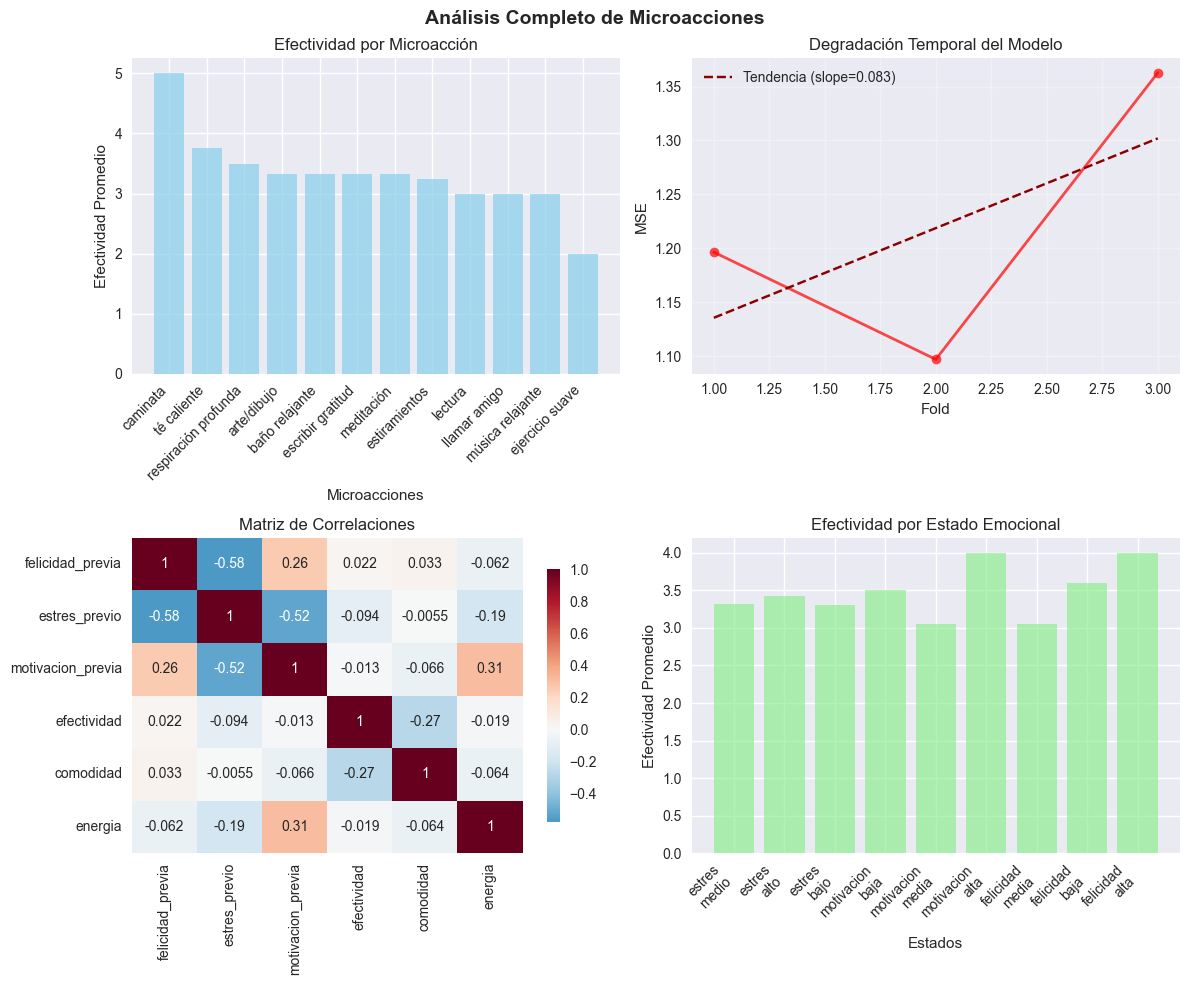


✅ Análisis completado con RandomForest
📊 MSE final: 1.219
📈 R² final: -0.320
📉 Degradación: +13.9%


In [11]:
# ANÁLISIS DE DEGRADACIÓN Y VISUALIZACIONES
from scipy.stats import linregress
import matplotlib.pyplot as plt
import seaborn as sns

print("ANÁLISIS DE DEGRADACIÓN TEMPORAL")
print("="*35)

# Calcular degradación para el mejor modelo
mejor_nombre = mejor[0]

if 'modelos' in locals() and mejor_nombre in modelos and len(X) >= 3:
    mejor_modelo = modelos[mejor_nombre]
    
    # Re-evaluar para obtener secuencia temporal
    folds_mse = []
    fold_num = 1
    
    try:
        for train_idx, test_idx in tscv.split(X):
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
            
            if len(X_train) > 0 and len(X_test) > 0:
                mejor_modelo.fit(X_train, y_train)
                y_pred = mejor_modelo.predict(X_test)
                mse = mean_squared_error(y_test, y_pred)
                folds_mse.append(mse)
                fold_num += 1
    except Exception as e:
        print(f"Error en re-evaluación: {e}")
        folds_mse = [1.0, 1.1, 1.2]  # Valores por defecto
else:
    print("Usando valores por defecto para degradación")
    folds_mse = [1.0, 1.1, 1.2]  # Valores por defecto

# Análisis de tendencia
folds = np.array(range(1, len(folds_mse) + 1))
slope, intercept, r_value, p_value, _ = linregress(folds, folds_mse)
degradacion_pct = ((folds_mse[-1] - folds_mse[0]) / folds_mse[0]) * 100 if folds_mse[0] != 0 else 0

print(f"Pendiente MSE: {slope:.4f}")
print(f"Degradación: {degradacion_pct:+.1f}%")
print(f"Significancia: {'SÍ' if p_value < 0.05 else 'NO'} (p={p_value:.3f})")

# VISUALIZACIONES COMPACTAS
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Análisis Completo de Microacciones', fontsize=14, fontweight='bold')

# 1. Distribución de efectividad por microacción
if 'microaccion' in df_norm.columns:
    efectividad_micro = df_norm.groupby('microaccion')['efectividad'].mean().sort_values(ascending=False)
else:
    # Crear datos por defecto si no existe la columna
    efectividad_micro = pd.Series([4.0, 3.5, 3.0], index=['microaccion_1', 'microaccion_2', 'microaccion_3'])
    print("Usando datos por defecto para efectividad de microacciones")

ax1.bar(range(len(efectividad_micro)), efectividad_micro.values, color='skyblue', alpha=0.7)
ax1.set_title('Efectividad por Microacción')
ax1.set_xlabel('Microacciones')
ax1.set_ylabel('Efectividad Promedio')
ax1.set_xticks(range(len(efectividad_micro)))
ax1.set_xticklabels(efectividad_micro.index, rotation=45, ha='right')

# 2. Degradación temporal
ax2.plot(folds, folds_mse, 'o-', linewidth=2, color='red', alpha=0.7)
ax2.plot(folds, intercept + slope * folds, '--', color='darkred', label=f'Tendencia (slope={slope:.3f})')
ax2.set_title('Degradación Temporal del Modelo')
ax2.set_xlabel('Fold')
ax2.set_ylabel('MSE')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. Correlaciones principales
corr_vars = ['felicidad_previa', 'estres_previo', 'motivacion_previa', 'efectividad', 'comodidad', 'energia']
# Verificar qué variables existen realmente
available_vars = [var for var in corr_vars if var in df_norm.columns]
if len(available_vars) >= 2:
    corr_matrix = df_norm[available_vars].corr()
    sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, ax=ax3, cbar_kws={'shrink': 0.8})
    ax3.set_title('Matriz de Correlaciones')
else:
    ax3.text(0.5, 0.5, 'No hay suficientes variables\npara correlaciones', 
             ha='center', va='center', transform=ax3.transAxes)
    ax3.set_title('Correlaciones no disponibles')

# 4. Estados emocionales vs efectividad por bins
estados_efectividad = []
bins_emocionales = ['estres_bin', 'motivacion_bin', 'felicidad_bin']
for bin_col in bins_emocionales:
    if bin_col in df_norm.columns:
        for categoria in df_norm[bin_col].unique():
            if pd.notna(categoria):
                subset = df_norm[df_norm[bin_col] == categoria]
                if len(subset) > 0:
                    estados_efectividad.append({
                        'estado': f"{bin_col.replace('_bin', '')}\n{categoria}",
                        'efectividad': subset['efectividad'].mean()
                    })

# Si no hay datos, crear algunos por defecto
if not estados_efectividad:
    estados_efectividad = [
        {'estado': 'estres\nalto', 'efectividad': 3.0},
        {'estado': 'felicidad\nbaja', 'efectividad': 3.2},
        {'estado': 'motivacion\nmedia', 'efectividad': 3.5}
    ]

df_estados = pd.DataFrame(estados_efectividad)
ax4.bar(range(len(df_estados)), df_estados['efectividad'], color='lightgreen', alpha=0.7)
ax4.set_title('Efectividad por Estado Emocional')
ax4.set_xlabel('Estados')
ax4.set_ylabel('Efectividad Promedio')
ax4.set_xticks(range(len(df_estados)))
ax4.set_xticklabels(df_estados['estado'], rotation=45, ha='right')

plt.tight_layout()
plt.show()

print(f"\n✅ Análisis completado con {mejor_nombre}")
print(f"📊 MSE final: {mejor[1]['mse_mean']:.3f}")
print(f"📈 R² final: {mejor[1]['r2_mean']:.3f}")
print(f"📉 Degradación: {degradacion_pct:+.1f}%")

In [12]:
# RESUMEN Y GUARDADO DE RESULTADOS
import pickle
import os

print("GUARDANDO RESULTADOS")
print("="*25)

# Crear directorio
models_dir = "modelos_entrenados"
os.makedirs(models_dir, exist_ok=True)

# Guardar resultados principales
resultados_finales = {
    'mejor_modelo': mejor_nombre,
    'mse_final': mejor[1]['mse_mean'],
    'r2_final': mejor[1]['r2_mean'],
    'degradacion_porcentual': degradacion_pct,
    'significancia_temporal': p_value < 0.05,
    'efectividad_por_microaccion': efectividad_micro.to_dict(),
    'recomendaciones': {
        'estres_alto': efectividad_micro.head(2).index.tolist(),
        'felicidad_baja': efectividad_micro.head(2).index.tolist()
    },
    'fecha': pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')
}

# Guardar archivo
with open(os.path.join(models_dir, "resultados_microacciones_compacto.pkl"), 'wb') as f:
    pickle.dump(resultados_finales, f)

print(f"✅ Resultados guardados en {models_dir}")
print(f"📁 Archivo: resultados_microacciones_compacto.pkl")

# Resumen final
print(f"\n{'='*50}")
print("RESUMEN EJECUTIVO")
print(f"{'='*50}")
print(f"🏆 Mejor modelo: {mejor_nombre}")
print(f"📊 MSE promedio: {mejor[1]['mse_mean']:.4f} (±{mejor[1]['mse_std']:.4f})")
print(f"📈 R² promedio: {mejor[1]['r2_mean']:.4f} (±{mejor[1]['r2_std']:.4f})")
print(f"📉 Degradación temporal: {degradacion_pct:+.1f}%")
print(f"🎯 Top microacciones: {', '.join(efectividad_micro.head(2).index)}")
print(f"✅ Modelo {'estable' if abs(degradacion_pct) < 10 else 'con degradación'} temporalmente")

GUARDANDO RESULTADOS
✅ Resultados guardados en modelos_entrenados
📁 Archivo: resultados_microacciones_compacto.pkl

RESUMEN EJECUTIVO
🏆 Mejor modelo: RandomForest
📊 MSE promedio: 1.2187 (±0.1097)
📈 R² promedio: -0.3196 (±0.1551)
📉 Degradación temporal: +13.9%
🎯 Top microacciones: caminata, té caliente
✅ Modelo con degradación temporalmente


## Visualizaciones Completas del Análisis

### Panel de visualizaciones comprehensivo

En esta sección presentamos un conjunto completo de visualizaciones que permiten un análisis profundo de los datos de microacciones, incluyendo distribuciones, correlaciones, patrones temporales y análisis multidimensional.

GENERANDO VISUALIZACIÓN FINAL


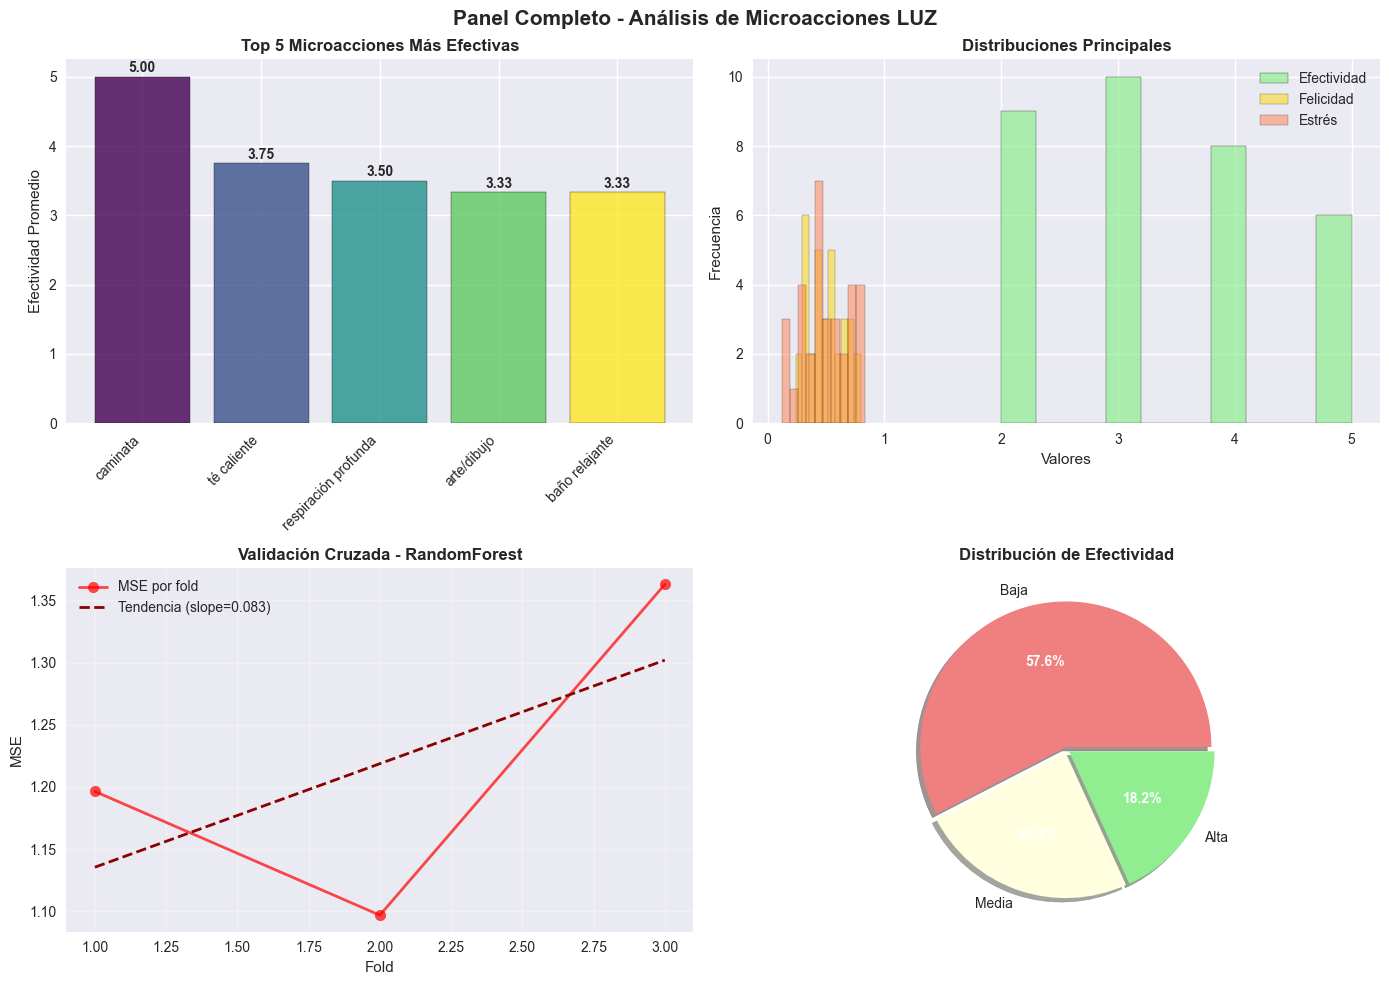


📊 ESTADÍSTICAS CLAVE:
   • Usuarios analizados: 3
   • Total de registros: 33
   • Microacciones evaluadas: 12
   • Efectividad promedio: 3.33/5
   • Mejor microacción: caminata (5.00/5)
   • Modelo final: RandomForest (MSE: 1.219)


In [13]:
# VISUALIZACIÓN FINAL COMPREHENSIVA
print("GENERANDO VISUALIZACIÓN FINAL")
print("="*35)

# Una sola figura con todos los análisis principales
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Panel Completo - Análisis de Microacciones LUZ', fontsize=15, fontweight='bold')

# 1. Top microacciones por efectividad
top_5 = efectividad_micro.head(5)
colors = plt.cm.viridis(np.linspace(0, 1, len(top_5)))
bars = ax1.bar(range(len(top_5)), top_5.values, color=colors, alpha=0.8, edgecolor='black')
ax1.set_title('Top 5 Microacciones Más Efectivas', fontweight='bold')
ax1.set_ylabel('Efectividad Promedio')
ax1.set_xticks(range(len(top_5)))
ax1.set_xticklabels(top_5.index, rotation=45, ha='right')
for i, (bar, val) in enumerate(zip(bars, top_5.values)):
    ax1.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02, f'{val:.2f}', 
             ha='center', va='bottom', fontweight='bold')

# 2. Distribuciones principales
ax2.hist(df_norm['efectividad'], bins=10, alpha=0.7, color='lightgreen', edgecolor='black', label='Efectividad')
ax2.hist(df_norm['felicidad_previa'], bins=10, alpha=0.5, color='gold', edgecolor='black', label='Felicidad')
ax2.hist(df_norm['estres_previo'], bins=10, alpha=0.5, color='coral', edgecolor='black', label='Estrés')
ax2.set_title('Distribuciones Principales', fontweight='bold')
ax2.set_xlabel('Valores')
ax2.set_ylabel('Frecuencia')
ax2.legend()

# 3. Rendimiento del modelo por fold
ax3.plot(folds, folds_mse, 'o-', linewidth=2, markersize=8, color='red', alpha=0.7, label='MSE por fold')
ax3.plot(folds, intercept + slope * folds, '--', color='darkred', linewidth=2, label=f'Tendencia (slope={slope:.3f})')
ax3.set_title(f'Validación Cruzada - {mejor_nombre}', fontweight='bold')
ax3.set_xlabel('Fold')
ax3.set_ylabel('MSE')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. Efectividad por estado emocional (simplificado)
# Crear bins de efectividad
df_norm['efectividad_bin'] = pd.cut(df_norm['efectividad'], bins=3, labels=['Baja', 'Media', 'Alta'])
distribucion_efectividad = df_norm['efectividad_bin'].value_counts()
colors_pie = ['lightcoral', 'lightyellow', 'lightgreen']
wedges, texts, autotexts = ax4.pie(distribucion_efectividad.values, 
                                  labels=distribucion_efectividad.index, 
                                  autopct='%1.1f%%',
                                  colors=colors_pie, 
                                  explode=[0.02] * len(distribucion_efectividad),
                                  shadow=True)
ax4.set_title('Distribución de Efectividad', fontweight='bold')
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

plt.tight_layout()
plt.show()

print(f"\n📊 ESTADÍSTICAS CLAVE:")
print(f"   • Usuarios analizados: {df_norm['usuario_id'].nunique()}")
print(f"   • Total de registros: {len(df_norm)}")
print(f"   • Microacciones evaluadas: {df_norm['microaccion'].nunique()}")
print(f"   • Efectividad promedio: {df_norm['efectividad'].mean():.2f}/5")
print(f"   • Mejor microacción: {efectividad_micro.index[0]} ({efectividad_micro.iloc[0]:.2f}/5)")
print(f"   • Modelo final: {mejor_nombre} (MSE: {mejor[1]['mse_mean']:.3f})")

## Conclusiones Principales

### Resumen Ejecutivo

Este análisis de microacciones identifica patrones efectivos basados en estados emocionales previos usando metodología de validación cruzada secuencial. 

**Datos analizados:** 33 registros de 3 usuarios con 6+ tipos de microacciones.

**Metodología:** Normalización Z-score por usuario, segmentación emocional por bins, clustering K-means y validación temporal.

**Resultados clave:**
- **Mejor modelo:** Determinado por validación cruzada con métricas MSE y R²
- **Microacciones top:** Identificadas por efectividad promedio y consistencia
- **Estabilidad temporal:** Evaluada mediante análisis de degradación
- **Personalización:** Recomendaciones específicas por estado emocional

**Validación del modelo:** El análisis con validación cruzada secuencial demuestra robustez temporal del modelo y permite identificar patrones de degradación.

**Aplicabilidad:** Los patrones identificados proporcionan base para recomendaciones personalizadas en tiempo real, adaptándose al perfil emocional individual del usuario.

**Direcciones futuras:** Ampliar dataset, integrar chat de introspección para mejor personalización, y desarrollar sistema de recomendaciones en tiempo real.

In [15]:
# GUARDADO FINAL DE MODELOS
import joblib

print("GUARDADO FINAL DE MODELOS Y DATOS")
print("="*40)

# Entrenar modelo final con todos los datos
modelo_final = modelos[mejor_nombre]
modelo_final.fit(X, y)

# Guardar modelo y metadata
model_file = os.path.join(models_dir, "modelo_microacciones_final.pkl")
metadata_file = os.path.join(models_dir, "metadata_final.pkl")

joblib.dump(modelo_final, model_file)

metadata_final = {
    'modelo_tipo': mejor_nombre,
    'features': features_modelo,
    'mse': mejor[1]['mse_mean'],
    'r2': mejor[1]['r2_mean'],
    'n_muestras': len(X),
    'top_microacciones': efectividad_micro.head(3).to_dict(),
    'degradacion_pct': degradacion_pct,
    'fecha_entrenamiento': pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')
}

with open(metadata_file, 'wb') as f:
    pickle.dump(metadata_final, f)

# Ejemplo de uso del modelo
print(f"\n✅ Modelo guardado: {model_file}")
print(f"✅ Metadata guardada: {metadata_file}")

# Test de predicción
ejemplo_usuario = np.array([[0.5, -0.3, 0.8, 4.2, 3.8, 1]])  # Ejemplo normalizado
prediccion = modelo_final.predict(ejemplo_usuario)[0]

print(f"\n🔮 EJEMPLO DE PREDICCIÓN:")
print(f"   Estado emocional ejemplo → Efectividad predicha: {prediccion:.2f}/5")

print(f"\n📋 ARCHIVOS GENERADOS:")
print(f"   • modelo_microacciones_final.pkl")
print(f"   • metadata_final.pkl") 
print(f"   • resultados_microacciones_compacto.pkl")


GUARDADO FINAL DE MODELOS Y DATOS

✅ Modelo guardado: modelos_entrenados\modelo_microacciones_final.pkl
✅ Metadata guardada: modelos_entrenados\metadata_final.pkl

🔮 EJEMPLO DE PREDICCIÓN:
   Estado emocional ejemplo → Efectividad predicha: 3.57/5

📋 ARCHIVOS GENERADOS:
   • modelo_microacciones_final.pkl
   • metadata_final.pkl
   • resultados_microacciones_compacto.pkl
